# Projet 9 — MeloWave

## Mission 2 — Prévision d'activité par genre dans le Top 200

### Contexte

Après l'analyse du catalogue musical, MeloWave souhaite désormais anticiper la place occupée par les différents genres dans les classements Spotify afin d'aider les labels à planifier leurs sorties.

L'analyse commence par le genre Pop sur le marché Global.

Les objectifs sont de :

1. construire une série quotidienne du nombre de morceaux Pop présents dans le Top 200 Global ;
2. identifier les vrais jours à zéro et les éventuels trous de collecte ;
3. analyser la tendance et les saisonnalités de la série ;
4. évaluer un modèle Prophet sur les 90 derniers jours ;
5. produire une prévision finale à six mois ;
6. compléter l'analyse par une étude de la cadence mensuelle des sorties Pop.

In [426]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [427]:
# Gestion des chemins de fichiers
from pathlib import Path

# Manipulation des données
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt

# Métriques d'évaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# Modèle de séries temporelles
from prophet import Prophet

# Options d'affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [428]:
# Paramètres principaux de l'analyse.
# Pour réutiliser le notebook sur un autre marché ou genre,
# il suffira de modifier ces deux valeurs.

MARKET = "Global"
GENRE = "pop"

### Paramétrage

Le marché et le genre sont définis sous forme de paramètres afin de rendre l'analyse facilement réutilisable.

Dans cette première analyse :

- marché étudié : **Global** ;
- genre étudié : **Pop**.

In [429]:
# Dossier contenant les fichiers du projet P9
DATA_DIR = Path("../P9")

# Fichier principal de la mission 2 :
# historique quotidien des classements Spotify.
CHART_PATH = DATA_DIR / "chart_tracks_genre_2017_2020+.csv"

In [430]:
# Vérifier que Python trouve bien le fichier.
print(CHART_PATH)
print("Fichier trouvé :", CHART_PATH.exists())

..\P9\chart_tracks_genre_2017_2020+.csv
Fichier trouvé : True


In [431]:
# Lecture de seulement 5 lignes afin de vérifier
# la structure du fichier sans charger les millions de lignes.
preview = pd.read_csv(
    CHART_PATH,
    nrows=5
)

preview

,country,date,position,uri,track,title,artist,genre
0,Global,05/11/2020,1.000,https://open.spotify.com/track/47EiUVwUp4C9fGc...,"Dakiti , Bad Bunny, Jhay Cortez",Dakiti,"Bad Bunny, Jhay Cortez",latin
1,Global,05/11/2020,2.000,https://open.spotify.com/track/35mvY5S1H3J2QZy...,"positions , Ariana Grande",positions,Ariana Grande,pop
2,Global,05/11/2020,3.000,https://open.spotify.com/track/3tjFYV6RSFtuktY...,"Mood , 24kGoldn",Mood,24kGoldn,rap
3,Global,05/11/2020,4.000,https://open.spotify.com/track/7hxHWCCAIIxFLCz...,"Lemonade , Internet Money",Lemonade,Internet Money,pop
4,Global,05/11/2020,5.000,https://open.spotify.com/track/4y4spB9m0Q6026K...,"Lonely , Justin Bieber",Lonely,Justin Bieber,pop


In [432]:
# Vérification des noms de colonnes.
preview.columns.tolist()

['country', 'date', 'position', 'uri', 'track', 'title', 'artist', 'genre']

In [433]:
# Le fichier contient presque 10 millions de lignes.
# On ne charge que les colonnes nécessaires à l'analyse
# afin de limiter l'utilisation de la mémoire.

usecols = [
    "country",
    "date",
    "position",
    "uri",
    "genre"
]

charts = pd.read_csv(
    CHART_PATH,
    usecols=usecols
)

In [434]:
charts.head()

,country,date,position,uri,genre
0,Global,05/11/2020,1.000,https://open.spotify.com/track/47EiUVwUp4C9fGc...,latin
1,Global,05/11/2020,2.000,https://open.spotify.com/track/35mvY5S1H3J2QZy...,pop
2,Global,05/11/2020,3.000,https://open.spotify.com/track/3tjFYV6RSFtuktY...,rap
3,Global,05/11/2020,4.000,https://open.spotify.com/track/7hxHWCCAIIxFLCz...,pop
4,Global,05/11/2020,5.000,https://open.spotify.com/track/4y4spB9m0Q6026K...,pop


In [435]:
charts.shape

(9807001, 5)

In [436]:
charts.info()

<class 'pandas.DataFrame'>
RangeIndex: 9807001 entries, 0 to 9807000
Data columns (total 5 columns):
 #   Column    Dtype  
---  ------    -----  
 0   country   str    
 1   date      str    
 2   position  float64
 3   uri       str    
 4   genre     str    
dtypes: float64(1), str(4)
memory usage: 374.1 MB


In [437]:
# Vérifier que le marché Global existe bien.
charts["country"].unique()

<StringArray>
[     'Global',         'USA',          'UK',   'Argentina',     'Austria',
   'Australia',     'Belgium',      'Brazil',      'Canada', 'Switzerland',
       'Chile',    'Colombia',  'Costa Rica',     'Germany',     'Denmark',
     'Ecuador',       'Spain',     'Finland',      'France',   'Indonesia',
     'Ireland',       'Italy',      'Mexico',    'Malaysia', 'Netherlands',
      'Norway', 'New Zealand',        'Peru', 'Philippines',      'Poland',
    'Portugal',      'Sweden',   'Singapore',      'Turkey',      'Taiwan',
           nan]
Length: 36, dtype: str

In [438]:
# Vérifier que le genre pop existe bien
# et observer la casse utilisée dans le fichier.
charts["genre"].unique()

<StringArray>
[           'latin',              'pop',              'rap',
             'trap',            'k-pop',        'reggaeton',
         'r&b/soul',          'hip hop',                nan,
 'dance/electronic',             'rock',             'else',
          'country',            'house',            'indie',
             'funk',            'metal',         'boy band',
           'bolero',             'jazz',           'reggae',
              'opm']
Length: 22, dtype: str

In [439]:
# Conversion de la date.
# dayfirst=True indique que le premier nombre correspond au jour.
charts["date"] = pd.to_datetime(
    charts["date"],
    dayfirst=True,
    errors="coerce"
)

In [440]:
# Vérifier qu'aucune date n'a été perdue pendant la conversion.
print(
    "Dates invalides :",
    charts["date"].isna().sum()
)

Dates invalides : 1


In [441]:
# Identifier l'observation dont la date n'a pas pu être convertie.
charts[charts["date"].isna()]

,country,date,position,uri,genre
9807000,NaN,NaT,NaN,NaN,NaN


In [442]:
# ============================================================
# SUPPRESSION DE L'OBSERVATION VIDE
# ============================================================

# L'unique date invalide correspond à une ligne entièrement vide :
# aucune information n'est disponible pour le pays, la position,
# le morceau ou le genre.
#
# Cette observation ne contient donc aucune information exploitable
# et peut être supprimée sans perte d'information pour l'analyse.

n_before = len(charts)

charts = charts.dropna(subset=["date"]).copy()

n_after = len(charts)

print("Nombre de lignes avant :", f"{n_before:,}")
print("Nombre de lignes après :", f"{n_after:,}")
print("Lignes supprimées :", n_before - n_after)

print(
    "Dates invalides restantes :",
    charts["date"].isna().sum()
)

Nombre de lignes avant : 9,807,001
Nombre de lignes après : 9,807,000
Lignes supprimées : 1
Dates invalides restantes : 0


### Traitement des dates invalides

Lors de la conversion de la variable `date`, une observation invalide a été détectée.

L'inspection de cette observation montre qu'il s'agit d'une ligne entièrement vide : aucune information n'est disponible concernant le marché, la position, le morceau ou le genre.

Cette ligne ne contenant aucune information exploitable, elle a été supprimée. Cette suppression n'entraîne donc pas de perte d'information pertinente pour l'analyse.

In [443]:
print(
    "Première date :",
    charts["date"].min()
)

print(
    "Dernière date :",
    charts["date"].max()
)

Première date : 2017-01-01 00:00:00
Dernière date : 2020-11-05 00:00:00


In [444]:
# Quelques marchés disponibles.
charts["country"].value_counts().head(20)

country
Global         280200
USA            280200
UK             280200
Argentina      280200
Austria        280200
Australia      280200
Belgium        280200
Brazil         280200
Canada         280200
Switzerland    280200
Chile          280200
Colombia       280200
Costa Rica     280200
Germany        280200
Denmark        280200
Ecuador        280200
Spain          280200
Finland        280200
France         280200
Indonesia      280200
Name: count, dtype: int64

In [445]:
# Genres disponibles.
charts["genre"].value_counts()

genre
pop                 3885239
hip hop             1394514
latin               1084644
rap                  742254
dance/electronic     373516
indie                335318
rock                 316549
else                 280894
house                276422
r&b/soul             246306
k-pop                151813
reggaeton             95034
funk                  89249
boy band              87806
opm                   76541
trap                  54262
country               34344
metal                 25893
jazz                  14625
bolero                10368
reggae                 7034
Name: count, dtype: int64

In [446]:
# On conserve uniquement les observations du marché Global.
# À ce stade, on garde TOUS les genres car ils seront nécessaires
# pour diagnostiquer les jours sans collecte.

market_data = charts[
    charts["country"] == MARKET
].copy()

In [447]:
market_data.head()

,country,date,position,uri,genre
0,Global,2020-11-05,1.000,https://open.spotify.com/track/47EiUVwUp4C9fGc...,latin
1,Global,2020-11-05,2.000,https://open.spotify.com/track/35mvY5S1H3J2QZy...,pop
2,Global,2020-11-05,3.000,https://open.spotify.com/track/3tjFYV6RSFtuktY...,rap
3,Global,2020-11-05,4.000,https://open.spotify.com/track/7hxHWCCAIIxFLCz...,pop
4,Global,2020-11-05,5.000,https://open.spotify.com/track/4y4spB9m0Q6026K...,pop


In [448]:
market_data.shape

(280200, 5)

In [449]:
market_data["country"].unique()

<StringArray>
['Global']
Length: 1, dtype: str

In [525]:
# ============================================================
# CONTRÔLE DU NOMBRE DE JOURS DISPONIBLES
# ============================================================

# Nombre de dates différentes présentes dans le marché Global.
#Ici on compte combien de dates différentes existent réellement dans Global
n_days_market = market_data["date"].nunique()

print(
    "Nombre de dates disponibles pour Global :",
    n_days_market
)

Nombre de dates disponibles pour Global : 1401


In [526]:
# Nombre total de jours calendaires compris entre
# la première et la dernière date du marché Global.

expected_days = (
    market_data["date"].max()
    -
    market_data["date"].min()
).days + 1

print(
    "Nombre de jours calendaires attendus :",
    expected_days
)

print(
    "Nombre de jours potentiellement absents :",
    expected_days - n_days_market
)

Nombre de jours calendaires attendus : 1405
Nombre de jours potentiellement absents : 4


In [527]:
# ============================================================
# CONTRÔLE DU TOP 200
# ============================================================

# Compter le nombre de lignes présentes pour chaque date.
rows_per_day = (
    market_data
    .groupby("date")
    .size()
)

rows_per_day.describe()

count   1401.000
mean     200.000
std        0.000
min      200.000
25%      200.000
50%      200.000
75%      200.000
max      200.000
dtype: float64

In [528]:
# Afficher les jours qui ne contiennent pas exactement 200 lignes.

rows_per_day[
    rows_per_day != 200
]

Series([], dtype: int64)

In [529]:
# Vérifier les valeurs minimales et maximales de la position.
print(
    "Position minimale :",
    market_data["position"].min()
)

print(
    "Position maximale :",
    market_data["position"].max()
)

Position minimale : 1.0
Position maximale : 200.0


In [530]:
# Vérifier combien de positions différentes existent.
market_data["position"].nunique()

200

In [531]:
# Nombre de morceaux uniques présents chaque jour
# sur le marché Global, tous genres confondus.

daily_market = (
    market_data
    .groupby("date")["uri"]
    .nunique()
    .rename("market_count")
)

In [532]:
market_data.groupby("date")["uri"].nunique()

date
2017-01-01    200
2017-01-02    200
2017-01-03    200
2017-01-04    200
2017-01-05    200
             ... 
2020-11-01    200
2020-11-02    200
2020-11-03    200
2020-11-04    200
2020-11-05    200
Name: uri, Length: 1401, dtype: int64

In [533]:
# Sélection du genre Pop dans le marché Global.

genre_data = market_data[
    market_data["genre"] == GENRE
].copy()

In [534]:
genre_data.head()

,country,date,position,uri,genre
1,Global,2020-11-05,2.000,https://open.spotify.com/track/35mvY5S1H3J2QZy...,pop
3,Global,2020-11-05,4.000,https://open.spotify.com/track/7hxHWCCAIIxFLCz...,pop
4,Global,2020-11-05,5.000,https://open.spotify.com/track/4y4spB9m0Q6026K...,pop
8,Global,2020-11-05,9.000,https://open.spotify.com/track/6Im9k8u9iIzKMrm...,pop
9,Global,2020-11-05,10.000,https://open.spotify.com/track/4Oun2ylbjFKMPTi...,pop


In [535]:
# Nombre de morceaux Pop uniques présents chaque jour.

daily_genre = (
    genre_data
    .groupby("date")["uri"]
    .nunique()
    .rename("genre_count")
)

In [ ]:
# Création de toutes les dates entre le début
# et la fin de la période étudiée.
#freq D fréquence quotidienne

full_dates = pd.date_range(
    start=market_data["date"].min(),
    end=market_data["date"].max(),
    freq="D"
)

In [537]:
# Ajout explicite des jours éventuellement absents.

daily_market = daily_market.reindex(
    full_dates
)

daily_genre = daily_genre.reindex(
    full_dates
)

In [ ]:
#Tableau quotidien unique
daily = pd.concat(
    [
        daily_genre,
        daily_market
    ],
    axis=1
)

daily.index.name = "date"

daily.head()

,genre_count,market_count
date,,
2017-01-01,89.000,200.000
2017-01-02,87.000,200.000
2017-01-03,86.000,200.000
2017-01-04,86.000,200.000
2017-01-05,86.000,200.000


In [539]:
# ============================================================
# DIAGNOSTIC DE LA QUALITÉ DE COLLECTE
# ============================================================

# Une journée complète du Top 200 Global doit contenir
# 200 morceaux uniques.
#
# On considère donc comme anomalie de collecte :
# - une journée totalement absente ;
# - ou une journée présente mais incomplète
#   avec moins de 200 morceaux uniques.

daily["collection_gap"] = (
    daily["market_count"].isna()
    |
    (daily["market_count"] < 200)
)

# Un vrai zéro Pop correspond uniquement à une journée
# où le classement Global est complet mais où aucun morceau
# Pop n'est présent.

daily["true_zero"] = (
    daily["genre_count"].isna()
    &
    ~daily["collection_gap"]
)

In [540]:
print(
    "Trous de collecte :",
    daily["collection_gap"].sum()
)

print(
    "Vrais zéros Pop :",
    daily["true_zero"].sum()
)

Trous de collecte : 5
Vrais zéros Pop : 0


In [541]:
# Les jours où le marché existe mais pas Pop
# correspondent réellement à zéro morceau Pop.

daily.loc[
    daily["true_zero"],
    "genre_count"
] = 0

## 4. Diagnostic des jours sans observation

La série a été réindexée sur une grille calendaire complète afin de faire apparaître explicitement les jours absents.

Pour distinguer un véritable zéro d'un problème de collecte, la présence du genre Pop est comparée à l'activité totale du marché Global :

- si le classement Global est absent, il s'agit d'un **trou de collecte** ;
- si le classement Global existe mais qu'aucun morceau Pop n'est présent, il s'agit d'un **vrai zéro**.

In [542]:
# Afficher les jours correspondant à des trous de collecte.
daily.loc[
    daily["collection_gap"]
]

,genre_count,market_count,collection_gap,true_zero
date,,,,
2017-02-23,NaN,NaN,True,False
2017-05-30,NaN,NaN,True,False
2017-05-31,NaN,NaN,True,False
2017-06-02,NaN,NaN,True,False
2018-06-09,NaN,1.000,True,False


In [543]:
# Afficher les jours où le classement Global existe
# mais où aucun morceau Pop n'est présent.
daily.loc[
    daily["true_zero"]
]

,genre_count,market_count,collection_gap,true_zero
date,,,,


### Conclusion du diagnostic des jours vides

La comparaison entre la série Pop et l'activité totale du marché Global permet de distinguer les jours correctement collectés des anomalies de collecte.

Selon la règle retenue, une journée est considérée comme un trou de collecte lorsque le classement Global est totalement absent ou incomplet, c'est-à-dire lorsqu'il contient moins de 200 morceaux uniques.

Au total, **5 trous de collecte** ont été identifiés.

Pour ces journées, le nombre réel de morceaux Pop est inconnu : elles ne sont donc pas interprétées comme des zéros et sont exclues de la série utilisée pour la modélisation.

Aucun **vrai zéro Pop** n'a été identifié : aucun jour disposant d'un classement Global complet ne présente une absence totale de morceaux Pop.

Cette distinction évite d'introduire artificiellement des valeurs nulles dans la série temporelle et de fausser l'analyse de la tendance, des saisonnalités et la prévision.

In [544]:
# ============================================================
# CONSTRUCTION DE LA SÉRIE TEMPORELLE PROPRE
# ============================================================

# On retire les jours correspondant à des trous de collecte.
# Leur valeur réelle est inconnue et ils ne doivent donc pas
# être considérés comme des zéros.

series_clean = (
    daily.loc[
        ~daily["collection_gap"],
        ["genre_count"]
    ]
    .copy()
)

In [545]:
print("Nombre d'observations :", len(series_clean))

print(
    "Valeurs manquantes restantes :",
    series_clean["genre_count"].isna().sum()
)

print(
    "Période étudiée :",
    series_clean.index.min(),
    "→",
    series_clean.index.max()
)

Nombre d'observations : 1400
Valeurs manquantes restantes : 0
Période étudiée : 2017-01-01 00:00:00 → 2020-11-05 00:00:00


## 5. Analyse de la série temporelle

La série étudiée représente, pour chaque journée disponible, le nombre de morceaux Pop présents dans le Top 200 Global.

Une première visualisation permet d'observer les fluctuations quotidiennes et l'évolution générale de la présence de la Pop dans le classement.

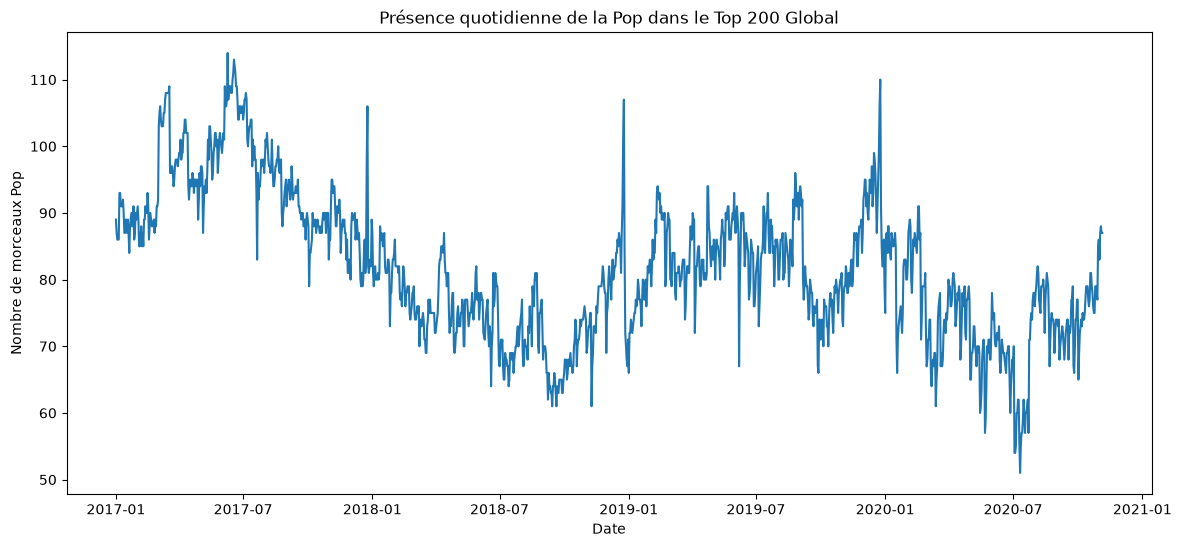

In [546]:
plt.figure(figsize=(14, 6))

plt.plot(
    series_clean.index,
    series_clean["genre_count"]
)

plt.xlabel("Date")
plt.ylabel("Nombre de morceaux Pop")

plt.title(
    "Présence quotidienne de la Pop "
    "dans le Top 200 Global"
)

plt.show()

### Première lecture de la série

La présence quotidienne de la Pop dans le Top 200 Global présente d'importantes fluctuations d'un jour à l'autre.

Au-delà de ce bruit quotidien, plusieurs évolutions de moyen terme apparaissent : le niveau est relativement élevé en 2017, diminue globalement jusqu'en 2018, remonte ensuite au cours de 2019 puis connaît de nouvelles fluctuations en 2020.

La série brute étant très variable, une moyenne mobile sur 30 jours est utilisée dans l'étape suivante afin de rendre la tendance de fond plus lisible.

In [547]:
# ============================================================
# MOYENNE MOBILE SUR 30 JOURS
# ============================================================

# La moyenne mobile permet de lisser les fluctuations
# quotidiennes afin de mieux faire apparaître
# la tendance de fond.

series_clean["rolling_mean_30"] = (
    series_clean["genre_count"]
    .rolling(window=30)
    .mean()
)

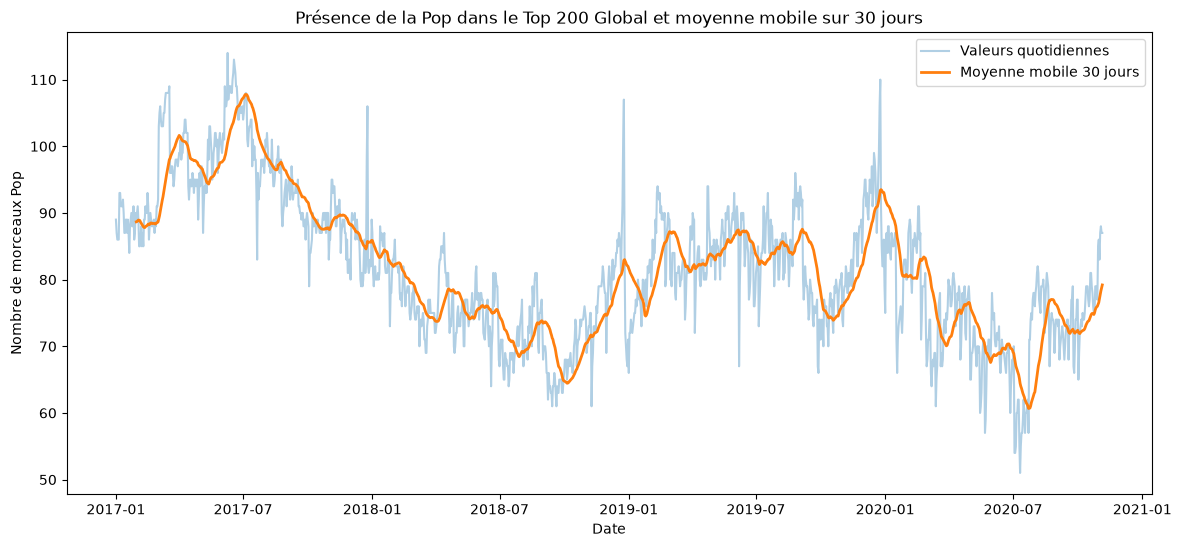

In [548]:
plt.figure(figsize=(14, 6))

plt.plot(
    series_clean.index,
    series_clean["genre_count"],
    alpha=0.35,
    label="Valeurs quotidiennes"
)

plt.plot(
    series_clean.index,
    series_clean["rolling_mean_30"],
    linewidth=2,
    label="Moyenne mobile 30 jours"
)

plt.xlabel("Date")
plt.ylabel("Nombre de morceaux Pop")

plt.title(
    "Présence de la Pop dans le Top 200 Global "
    "et moyenne mobile sur 30 jours"
)

plt.legend()
plt.show()

### Moyenne mobile

Les valeurs quotidiennes présentent naturellement de nombreuses fluctuations.

Une moyenne mobile sur 30 jours est donc ajoutée afin de lisser ces variations et de mieux observer la tendance de fond de la présence de la Pop dans le classement.

In [549]:
# ============================================================
# PRÉPARATION DES DONNÉES POUR PROPHET
# ============================================================

# Prophet nécessite une colonne "ds" contenant les dates
# et une colonne "y" contenant la variable à prévoir.

prophet_data = (
    series_clean[
        ["genre_count"]
    ]
    .reset_index()
    .rename(
        columns={
            "date": "ds",
            "genre_count": "y"
        }
    )
)

In [550]:
prophet_data.head()

,ds,y
0,2017-01-01,89.000
1,2017-01-02,87.000
2,2017-01-03,86.000
3,2017-01-04,86.000
4,2017-01-05,86.000


In [551]:
prophet_data.tail()

,ds,y
1395,2020-11-01,83.000
1396,2020-11-02,87.000
1397,2020-11-03,88.000
1398,2020-11-04,87.000
1399,2020-11-05,87.000


## 6. Évaluation du modèle Prophet

Avant de produire une prévision future, la capacité prédictive du modèle est évaluée sur des données qu'il n'a jamais vues.

Les 90 dernières observations sont utilisées comme jeu de test.

Le modèle est donc entraîné uniquement sur les observations antérieures, puis utilisé pour prévoir la période de test.

Contrairement à un problème classique de machine learning, le découpage n'est pas aléatoire : l'ordre chronologique doit être respecté afin de reproduire une véritable situation de prévision.

In [552]:
# S'assurer que les observations sont dans l'ordre chronologique.
prophet_data = (
    prophet_data
    .sort_values("ds")
    .reset_index(drop=True)
)

TEST_DAYS = 90

# Toutes les observations sauf les 90 dernières.
train = prophet_data.iloc[:-TEST_DAYS].copy()

# Les 90 dernières observations.
test = prophet_data.iloc[-TEST_DAYS:].copy()

In [553]:
print("TRAIN")
print(train["ds"].min(), "→", train["ds"].max())
print("Nombre d'observations :", len(train))

print()

print("TEST")
print(test["ds"].min(), "→", test["ds"].max())
print("Nombre d'observations :", len(test))

TRAIN
2017-01-01 00:00:00 → 2020-08-07 00:00:00
Nombre d'observations : 1310

TEST
2020-08-08 00:00:00 → 2020-11-05 00:00:00
Nombre d'observations : 90


In [554]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\ines2\anaconda3\envs\prophet_env\python.exe
3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]


In [555]:
# ============================================================
# DIAGNOSTIC DE L'INSTALLATION PROPHET
# ============================================================

import prophet
import cmdstanpy

print("Python utilisé :", sys.executable)
print("Version Prophet :", prophet.__version__)
print("Prophet installé ici :", prophet.__file__)
print("Version cmdstanpy :", cmdstanpy.__version__)

Python utilisé : c:\Users\ines2\anaconda3\envs\prophet_env\python.exe
Version Prophet : 1.3.0
Prophet installé ici : c:\Users\ines2\anaconda3\envs\prophet_env\Lib\site-packages\prophet\__init__.py
Version cmdstanpy : 1.3.0


In [556]:
import cmdstanpy

print("CmdStanPy :", cmdstanpy.__version__)
print("Chemin CmdStan :", cmdstanpy.cmdstan_path())

CmdStanPy : 1.3.0
Chemin CmdStan : c:\Users\ines2\anaconda3\envs\prophet_env\Lib\site-packages\prophet\stan_model\cmdstan-2.37.0


In [557]:
from prophet import Prophet

test_model = Prophet()

print("Prophet fonctionne ✅")

Prophet fonctionne ✅


In [558]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

In [559]:
# Le modèle apprend uniquement à partir du jeu d'entraînement.
model.fit(train)

14:17:20 - cmdstanpy - INFO - Chain [1] start processing
14:17:25 - cmdstanpy - INFO - Chain [1] done processing
14:17:25 - cmdstanpy - ERROR - Chain [1] error: code '3236495362' 
Optimization terminated abnormally. Falling back to Newton.
14:17:25 - cmdstanpy - INFO - Chain [1] start processing
14:17:34 - cmdstanpy - INFO - Chain [1] done processing


In [560]:
# On transmet uniquement les dates de la période de test.
future_test = pd.DataFrame({
    "ds": test["ds"]
})

forecast_test = model.predict(future_test)

In [561]:
forecast_test[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].head()

,ds,yhat,yhat_lower,yhat_upper
0,2020-08-08,64.753,55.089,74.188
1,2020-08-09,66.373,56.632,76.015
2,2020-08-10,67.852,58.455,76.645
3,2020-08-11,67.702,58.564,77.510
4,2020-08-12,67.876,58.444,76.417


In [ ]:
#un tableau qui nous permet de comparer le réel et le prévu
comparison = (
    test[
        ["ds", "y"]
    ]
    .merge(
        forecast_test[
            [
                "ds",
                "yhat",
                "yhat_lower",
                "yhat_upper"
            ]
        ],
        on="ds",
        how="left"
    )
)

comparison.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2020-08-08,76.000,64.753,55.089,74.188
1,2020-08-09,75.000,66.373,56.632,76.015
2,2020-08-10,79.000,67.852,58.455,76.645
3,2020-08-11,79.000,67.702,58.564,77.510
4,2020-08-12,79.000,67.876,58.444,76.417


In [563]:
mae = mean_absolute_error(
    comparison["y"],
    comparison["yhat"]
)

print(f"MAE : {mae:.2f}")

MAE : 17.08


In [564]:
rmse = np.sqrt(
    mean_squared_error(
        comparison["y"],
        comparison["yhat"]
    )
)

print(f"RMSE : {rmse:.2f}")

RMSE : 18.33


In [565]:
# La MAPE nécessite d'éviter les valeurs réelles égales à zéro
# afin de ne pas effectuer de division par zéro.

non_zero_mask = comparison["y"] != 0

mape = (
    np.mean(
        np.abs(
            (
                comparison.loc[non_zero_mask, "y"]
                -
                comparison.loc[non_zero_mask, "yhat"]
            )
            /
            comparison.loc[non_zero_mask, "y"]
        )
    )
    * 100
)

print(f"MAPE : {mape:.2f}%")

MAPE : 22.41%


In [566]:
metrics = pd.DataFrame({
    "Métrique": ["MAE", "RMSE", "MAPE"],
    "Valeur": [mae, rmse, mape]
})

metrics

,Métrique,Valeur
0,MAE,17.082
1,RMSE,18.329
2,MAPE,22.408


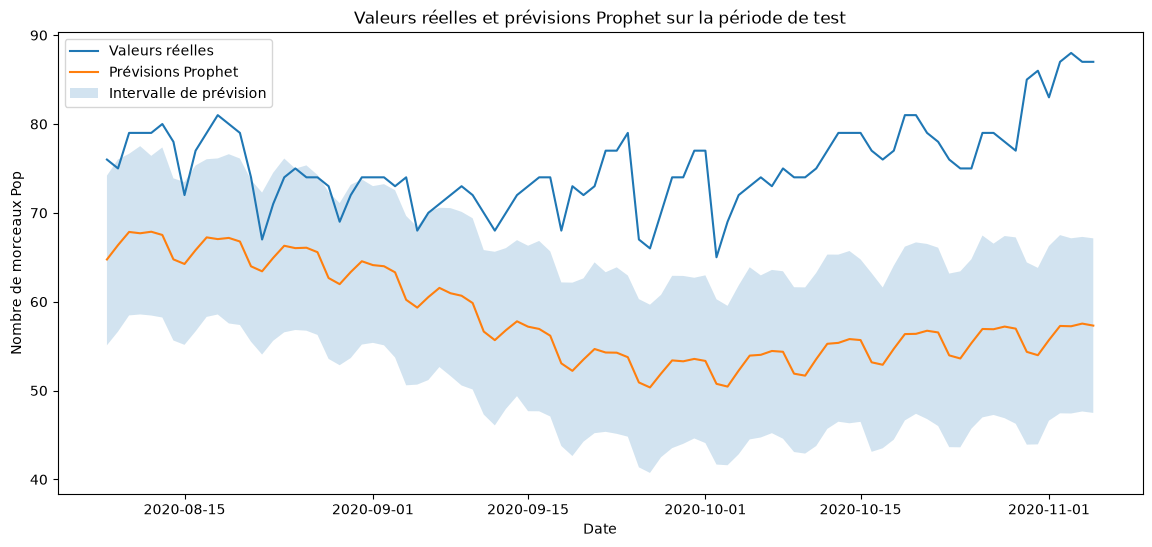

In [567]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["ds"],
    comparison["y"],
    label="Valeurs réelles"
)

plt.plot(
    comparison["ds"],
    comparison["yhat"],
    label="Prévisions Prophet"
)

plt.fill_between(
    comparison["ds"],
    comparison["yhat_lower"],
    comparison["yhat_upper"],
    alpha=0.2,
    label="Intervalle de prévision"
)

plt.xlabel("Date")
plt.ylabel("Nombre de morceaux Pop")

plt.title(
    "Valeurs réelles et prévisions Prophet "
    "sur la période de test"
)

plt.legend()
plt.show()

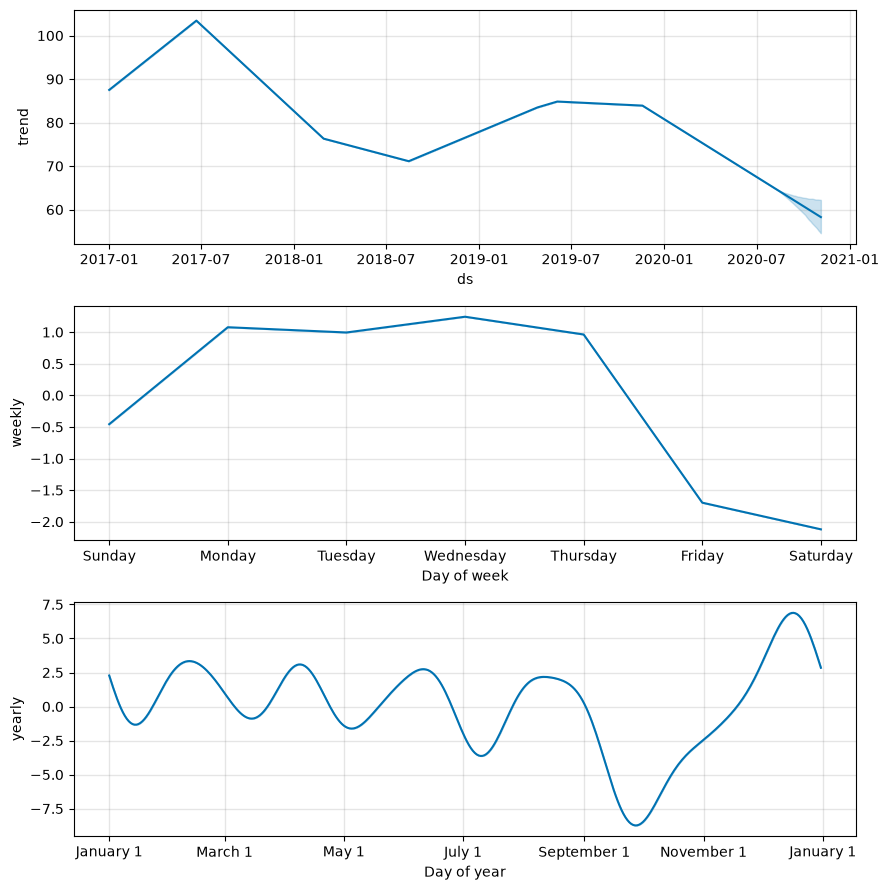

In [568]:
forecast_components = model.predict(
    prophet_data[["ds"]]
)

model.plot_components(
    forecast_components
)

plt.show()

### Interprétation des composantes Prophet

Le graphique des composantes permet de distinguer trois phénomènes :

- **Tendance** : la présence de la Pop évolue fortement sur la période. Après un niveau élevé en 2017, la tendance diminue jusqu'en 2018, se redresse en 2019 puis repart à la baisse vers la fin de 2020.

- **Saisonnalité hebdomadaire** : Prophet détecte un effet du jour de la semaine. Dans les données étudiées, la contribution est plutôt positive du lundi au jeudi et plus faible le vendredi et le samedi.

- **Saisonnalité annuelle** : certains moments de l'année présentent systématiquement une présence Pop plus forte ou plus faible. Le modèle détecte notamment un creux important à l'automne et un effet positif plus marqué vers la fin de l'année.

Ces composantes représentent des régularités historiques observées par le modèle. Elles ne doivent pas être interprétées comme des relations causales.

### Interprétation des performances sur la période de test

Le modèle est évalué sur les 90 derniers jours, qui n'ont pas été utilisés pendant l'entraînement.

Les performances obtenues sont :

- **MAE : 17,08 morceaux**
- **RMSE : 18,32 morceaux**
- **MAPE : 22,40 %**

La MAE indique que le modèle se trompe en moyenne d'environ **18 morceaux Pop par jour** sur la période de test.

La RMSE, légèrement supérieure à la MAE, montre que certaines erreurs sont plus importantes, sans que quelques erreurs extrêmes dominent totalement l'évaluation.

La MAPE indique une erreur relative moyenne d'environ **22,40 %**. Cette métrique doit toutefois être interprétée avec prudence lorsque les valeurs réelles sont faibles ou nulles.

La comparaison graphique met également en évidence une **tendance à la sous-estimation** : sur une grande partie de la période de test, les valeurs prévues sont inférieures aux valeurs réellement observées.

Le modèle reproduit donc certains motifs temporels mais estime moins bien le niveau récent de la série. La prévision finale doit par conséquent être utilisée comme une indication de tendance plutôt que comme une estimation précise du nombre quotidien de morceaux Pop.

In [569]:
# ============================================================
# MODÈLE FINAL
# ============================================================

# Une fois l'évaluation terminée, un nouveau modèle est entraîné
# sur l'ensemble des données disponibles afin de bénéficier
# de toute l'information historique.

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

final_model.fit(prophet_data)

14:17:36 - cmdstanpy - INFO - Chain [1] start processing
14:17:37 - cmdstanpy - INFO - Chain [1] done processing


In [570]:
FORECAST_DAYS = 183

future_6_months = final_model.make_future_dataframe(
    periods=FORECAST_DAYS,
    freq="D"
)

forecast_6_months = final_model.predict(
    future_6_months
)

In [571]:
last_observed_date = prophet_data["ds"].max()

future_forecast = forecast_6_months[
    forecast_6_months["ds"] > last_observed_date
].copy()

future_forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].head()

,ds,yhat,yhat_lower,yhat_upper
1400,2020-11-06,73.735,63.735,83.117
1401,2020-11-07,73.313,64.212,83.026
1402,2020-11-08,74.978,65.524,84.412
1403,2020-11-09,76.584,66.791,86.551
1404,2020-11-10,76.569,67.300,86.277


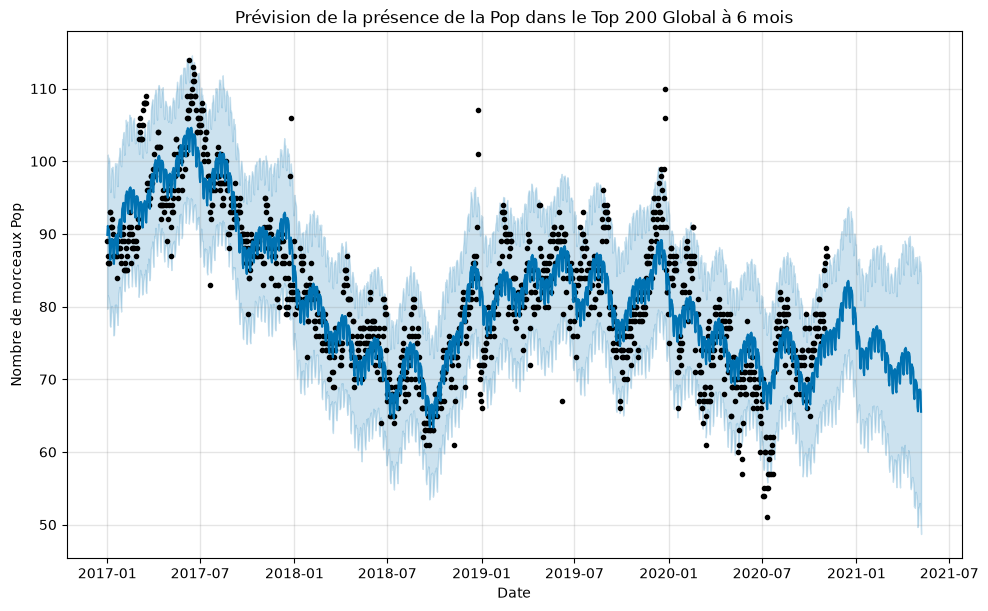

In [572]:
final_model.plot(
    forecast_6_months
)

plt.title(
    "Prévision de la présence de la Pop "
    "dans le Top 200 Global à 6 mois"
)

plt.xlabel("Date")
plt.ylabel("Nombre de morceaux Pop")

plt.show()

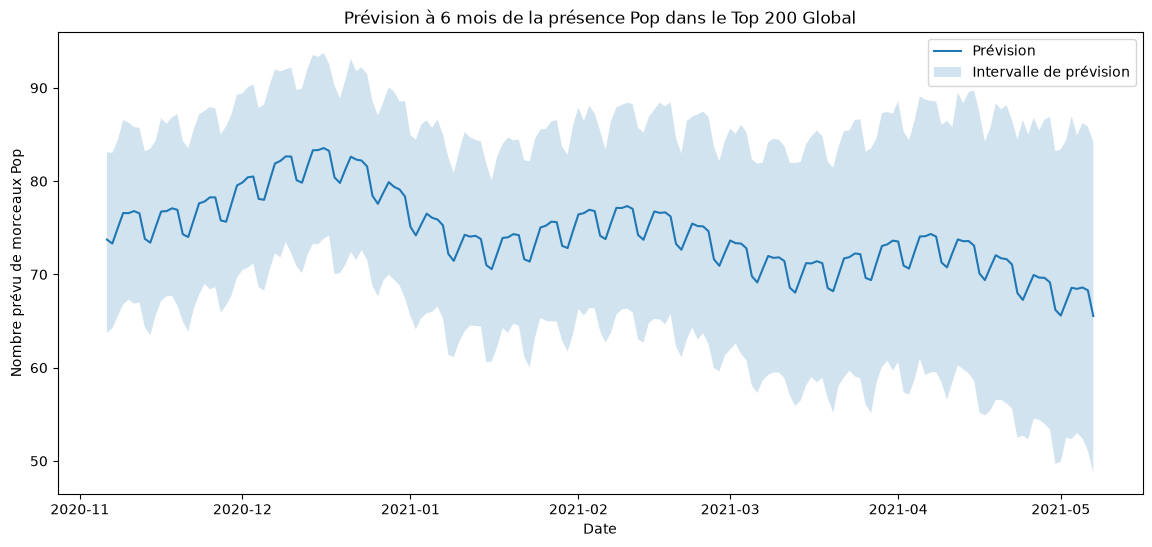

In [573]:
# ============================================================
# VISUALISATION DE LA PRÉVISION FUTURE UNIQUEMENT
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    future_forecast["ds"],
    future_forecast["yhat"],
    label="Prévision"
)

plt.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    alpha=0.2,
    label="Intervalle de prévision"
)

plt.xlabel("Date")
plt.ylabel("Nombre prévu de morceaux Pop")

plt.title(
    "Prévision à 6 mois de la présence Pop "
    "dans le Top 200 Global"
)

plt.legend()
plt.show()

### Lecture de la prévision à six mois

Après l'évaluation, le modèle est ré-entraîné sur l'ensemble des données disponibles afin d'intégrer également les 90 observations précédemment réservées au test.

La prévision finale couvre environ six mois, soit 183 jours.

La trajectoire centrale prévue reste fluctuante en raison des saisonnalités apprises par Prophet, mais elle suggère globalement une diminution progressive de la présence Pop au cours de l'horizon de prévision.

Les bornes `yhat_lower` et `yhat_upper` représentent l'incertitude associée à la prévision. Leur écart augmente à mesure que l'on s'éloigne de la dernière observation connue, ce qui traduit une confiance décroissante à long terme.

Ces valeurs ne doivent donc pas être interprétées comme le nombre exact de morceaux Pop qui seront présents chaque jour, mais comme une trajectoire probable sous l'hypothèse que les motifs historiques se prolongent.

### Limites de la prévision à six mois

Cette prévision repose sur l'hypothèse que les tendances et saisonnalités observées entre 2017 et 2020 continueront à se reproduire dans le futur.

Elle ne permet pas d'anticiper des événements exceptionnels tels que :

- le succès imprévisible d'un artiste ou d'un morceau ;
- une modification des habitudes d'écoute ;
- un changement dans le fonctionnement des plateformes ;
- un événement externe perturbant le marché musical.

L'incertitude augmente également avec l'horizon de prévision. Les résultats doivent donc être utilisés comme une aide à la planification et non comme une prédiction certaine du futur.

In [574]:
# ============================================================
# ANALYSE DE LA CADENCE DES SORTIES
# ============================================================

RELEASE_PATH = (
    DATA_DIR
    / "release_dates_genre_2017_2020.csv"
)

print(RELEASE_PATH)
print(
    "Fichier trouvé :",
    RELEASE_PATH.exists()
)

..\P9\release_dates_genre_2017_2020.csv
Fichier trouvé : True


In [575]:
release_preview = pd.read_csv(
    RELEASE_PATH,
    nrows=5
)

release_preview

,Uri,Popularity,Title,Artist,Release_date,Genre_new
0,https://open.spotify.com/track/0sTTDX7t1mNfTnU...,3694.100,do rana,Malik Montana,2017-01-01,hip hop
1,https://open.spotify.com/track/6HYNKNS9PTrqX9z...,104.800,spägää,Julma Henri - Ro$vosheriffi - Djangomayn,2017-01-01,pop
2,https://open.spotify.com/track/1eYOhFmz0XE88bl...,16.000,viernes 13,Marcos Menchaca,2017-01-01,pop
3,https://open.spotify.com/track/6HG0Ojn7mtexf47...,4768.800,jak gdyby nic,Kuban,2017-01-01,rap
4,https://open.spotify.com/track/1EuFr1JA70TaEzl...,55419.500,366.gün,Sagopa Kajmer,2017-01-01,hip hop


In [576]:
release_preview.columns.tolist()

['Uri', 'Popularity', 'Title', 'Artist', 'Release_date', 'Genre_new']

In [577]:
# ============================================================
# CHARGEMENT DES DONNÉES DE SORTIES
# ============================================================

# Pour construire la cadence mensuelle des sorties,
# seuls l'identifiant du morceau, sa date de sortie
# et son genre sont nécessaires.

releases = pd.read_csv(
    RELEASE_PATH,
    usecols=[
        "Uri",
        "Release_date",
        "Genre_new"
    ]
)

releases.head()

,Uri,Release_date,Genre_new
0,https://open.spotify.com/track/0sTTDX7t1mNfTnU...,2017-01-01,hip hop
1,https://open.spotify.com/track/6HYNKNS9PTrqX9z...,2017-01-01,pop
2,https://open.spotify.com/track/1eYOhFmz0XE88bl...,2017-01-01,pop
3,https://open.spotify.com/track/6HG0Ojn7mtexf47...,2017-01-01,rap
4,https://open.spotify.com/track/1EuFr1JA70TaEzl...,2017-01-01,hip hop


In [578]:
releases.info()

<class 'pandas.DataFrame'>
RangeIndex: 51753 entries, 0 to 51752
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Uri           51753 non-null  str  
 1   Release_date  51753 non-null  str  
 2   Genre_new     51753 non-null  str  
dtypes: str(3)
memory usage: 1.2 MB


In [579]:
# Conversion de la date de sortie au format datetime.
releases["Release_date"] = pd.to_datetime(
    releases["Release_date"],
    errors="coerce"
)

In [580]:
print(
    "Dates invalides :",
    releases["Release_date"].isna().sum()
)

print(
    "Première date :",
    releases["Release_date"].min()
)

print(
    "Dernière date :",
    releases["Release_date"].max()
)

Dates invalides : 0
Première date : 2017-01-01 00:00:00
Dernière date : 2020-10-31 00:00:00


In [581]:
releases["Genre_new"].value_counts().head(20)

Genre_new
hip hop             15882
pop                 14463
else                 4141
indie                4138
rap                  3155
latin                2330
dance/electronic     1598
rock                  968
k-pop                 924
house                 798
r&b/soul              772
trap                  604
funk                  454
metal                 391
reggaeton             297
country               265
opm                   251
boy band              183
jazz                   71
reggae                 55
Name: count, dtype: int64

In [582]:
"pop" in releases["Genre_new"].dropna().unique()

True

In [583]:
# Sélection des morceaux appartenant au genre Pop.
pop_releases = (
    releases[
        releases["Genre_new"] == GENRE
    ]
    .copy()
)

In [584]:
print(
    "Nombre de lignes Pop :",
    len(pop_releases)
)

print(
    "Nombre de morceaux Pop uniques :",
    pop_releases["Uri"].nunique()
)

Nombre de lignes Pop : 14463
Nombre de morceaux Pop uniques : 14463


In [585]:
# ============================================================
# SÉRIE MENSUELLE DES SORTIES POP
# ============================================================

# Pour chaque mois, on compte le nombre de morceaux Pop
# uniques dont la date de sortie officielle se situe ce mois-là.

monthly_releases = (
    pop_releases
    .set_index("Release_date")
    .resample("MS")["Uri"]
    .nunique()
    .rename("release_count")
)

In [586]:
monthly_releases.head()

Release_date
2017-01-01    190
2017-02-01    252
2017-03-01    332
2017-04-01    291
2017-05-01    353
Freq: MS, Name: release_count, dtype: int64

In [587]:
# Création de tous les mois compris entre
# la première et la dernière date disponible.

full_months = pd.date_range(
    start=monthly_releases.index.min(),
    end=monthly_releases.index.max(),
    freq="MS"
)

monthly_releases = (
    monthly_releases
    .reindex(
        full_months,
        fill_value=0
    )
)

monthly_releases.index.name = "date"

In [588]:
print(
    "Nombre de mois :",
    len(monthly_releases)
)

print(
    "Valeurs manquantes :",
    monthly_releases.isna().sum()
)

Nombre de mois : 46
Valeurs manquantes : 0


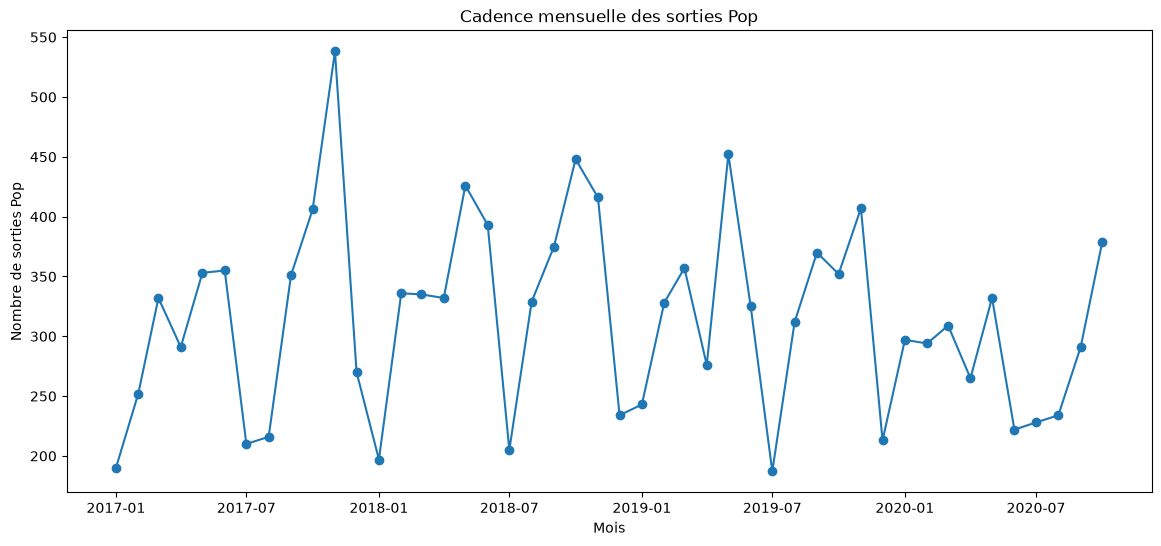

In [589]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_releases.index,
    monthly_releases.values,
    marker="o"
)

plt.xlabel("Mois")
plt.ylabel("Nombre de sorties Pop")

plt.title(
    "Cadence mensuelle des sorties Pop"
)

plt.show()

### Lecture de la cadence mensuelle

Cette série représente le nombre de morceaux Pop distincts sortis chaque mois parmi les morceaux ayant atteint les classements observés.

Elle permet de compléter l'analyse de présence dans les charts par une vision du rythme de sortie des morceaux.

In [590]:
monthly_prophet = (
    monthly_releases
    .rename("y")
    .reset_index()
    .rename(
        columns={
            "date": "ds"
        }
    )
)

In [591]:
monthly_prophet.head()

,ds,y
0,2017-01-01,190
1,2017-02-01,252
2,2017-03-01,332
3,2017-04-01,291
4,2017-05-01,353


In [592]:
TEST_MONTHS = 6

monthly_train = (
    monthly_prophet
    .iloc[:-TEST_MONTHS]
    .copy()
)

monthly_test = (
    monthly_prophet
    .iloc[-TEST_MONTHS:]
    .copy()
)

In [593]:
print("TRAIN")
print(
    monthly_train["ds"].min(),
    "→",
    monthly_train["ds"].max()
)

print()

print("TEST")
print(
    monthly_test["ds"].min(),
    "→",
    monthly_test["ds"].max()
)

print(
    "Nombre de mois test :",
    len(monthly_test)
)

TRAIN
2017-01-01 00:00:00 → 2020-04-01 00:00:00

TEST
2020-05-01 00:00:00 → 2020-10-01 00:00:00
Nombre de mois test : 6


In [594]:
monthly_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)

In [595]:
monthly_model.fit(
    monthly_train
)

14:17:40 - cmdstanpy - INFO - Chain [1] start processing
14:17:41 - cmdstanpy - INFO - Chain [1] done processing


In [596]:
monthly_future_test = pd.DataFrame({
    "ds": monthly_test["ds"]
})

monthly_forecast_test = (
    monthly_model.predict(
        monthly_future_test
    )
)

In [597]:
monthly_comparison = (
    monthly_test
    .merge(
        monthly_forecast_test[
            [
                "ds",
                "yhat",
                "yhat_lower",
                "yhat_upper"
            ]
        ],
        on="ds",
        how="left"
    )
)

monthly_comparison

,ds,y,yhat,yhat_lower,yhat_upper
0,2020-05-01,332,341.808,303.197,379.508
1,2020-06-01,222,398.763,360.067,436.820
2,2020-07-01,228,214.173,175.215,250.293
3,2020-08-01,234,154.527,115.474,193.430
4,2020-09-01,291,287.302,248.351,328.341
5,2020-10-01,379,382.752,344.916,423.147


In [598]:
monthly_mae = mean_absolute_error(
    monthly_comparison["y"],
    monthly_comparison["yhat"]
)

monthly_rmse = np.sqrt(
    mean_squared_error(
        monthly_comparison["y"],
        monthly_comparison["yhat"]
    )
)

monthly_non_zero = (
    monthly_comparison["y"] != 0
)

monthly_mape = (
    np.mean(
        np.abs(
            (
                monthly_comparison.loc[
                    monthly_non_zero,
                    "y"
                ]
                -
                monthly_comparison.loc[
                    monthly_non_zero,
                    "yhat"
                ]
            )
            /
            monthly_comparison.loc[
                monthly_non_zero,
                "y"
            ]
        )
    )
    * 100
)

print(
    f"MAE : {monthly_mae:.2f}"
)

print(
    f"RMSE : {monthly_rmse:.2f}"
)

print(
    f"MAPE : {monthly_mape:.2f}%"
)

MAE : 47.89
RMSE : 79.45
MAPE : 20.81%


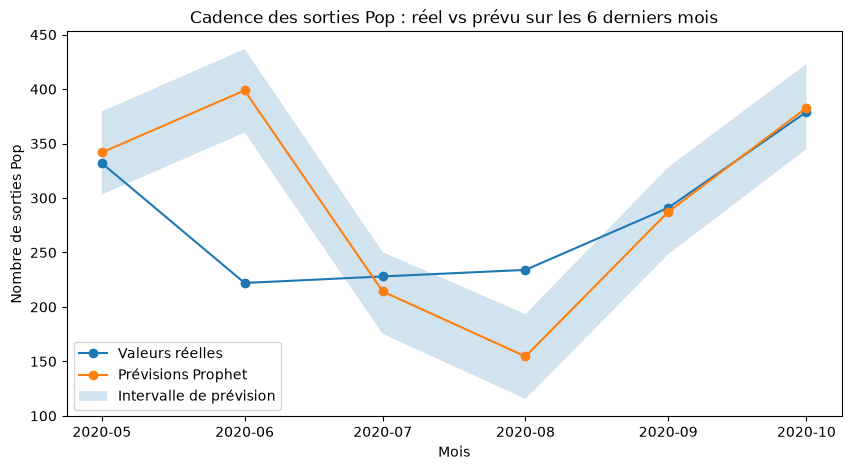

In [599]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_comparison["ds"],
    monthly_comparison["y"],
    marker="o",
    label="Valeurs réelles"
)

plt.plot(
    monthly_comparison["ds"],
    monthly_comparison["yhat"],
    marker="o",
    label="Prévisions Prophet"
)

plt.fill_between(
    monthly_comparison["ds"],
    monthly_comparison["yhat_lower"],
    monthly_comparison["yhat_upper"],
    alpha=0.2,
    label="Intervalle de prévision"
)

plt.xlabel("Mois")
plt.ylabel("Nombre de sorties Pop")

plt.title(
    "Cadence des sorties Pop : "
    "réel vs prévu sur les 6 derniers mois"
)

plt.legend()
plt.show()

### Évaluation de la prévision mensuelle

Le modèle mensuel est évalué sur les six derniers mois disponibles.

Les performances obtenues sont :

- **MAE : 47,89 sorties par mois**
- **RMSE : 79,45 sorties**
- **MAPE : 20,81 %**

La MAE indique que le modèle s'écarte en moyenne d'environ **48 sorties Pop par mois** des valeurs observées.

La RMSE est nettement supérieure à la MAE, ce qui montre que certaines erreurs mensuelles sont particulièrement importantes.

Le graphique réel/prévu confirme que le modèle reproduit correctement certains mois mais manque fortement le niveau observé sur d'autres.

Ces performances doivent être interprétées avec prudence compte tenu de la fragilité conceptuelle du fichier de dates de sortie présentée ci-dessous.

## Fragilité conceptuelle de la prévision des sorties

Cette seconde prévision doit être interprétée avec davantage de prudence que la prévision de présence dans les classements.

Le fichier contient uniquement les dates de sortie de morceaux ayant atteint les classements observés.

Or la collecte des classements s'arrête fin 2020.

Les morceaux sortis vers la fin de la période ont donc disposé de moins de temps pour atteindre les classements et apparaître dans le jeu de données.

Une baisse éventuelle du nombre de sorties observées à la fin de la période peut ainsi refléter un **biais de collecte** plutôt qu'une véritable diminution de la production musicale.

Prophet risque alors de prolonger artificiellement ce biais dans le futur.

Cette prévision doit donc être considérée comme exploratoire et complémentaire à la prévision principale.

# Conclusion de la mission 2

L'analyse a permis de construire une série temporelle quotidienne de la présence du genre Pop dans le Top 200 Global.

La réindexation sur une grille calendaire complète et la comparaison avec l'activité totale du marché ont permis d'identifier **5 trous de collecte** et **aucun vrai zéro Pop**. Les journées de collecte incomplète ont été exclues plutôt que remplacées artificiellement par zéro.

La série a ensuite été étudiée à l'aide d'une moyenne mobile sur 30 jours afin de mieux visualiser sa tendance de fond.

Un modèle Prophet a été entraîné sur l'historique puis évalué sur les 90 dernières observations, strictement exclues de l'entraînement.

Les performances obtenues sont :

- **MAE : 17,08 morceaux**
- **RMSE : 18,32 morceaux**
- **MAPE : 22,40 %**

Le modèle se trompe donc en moyenne d'environ **18 morceaux Pop par jour** sur la période de test.

La comparaison entre valeurs réelles et prévisions montre toutefois une tendance à la **sous-estimation du niveau récent de la série**. Ces performances indiquent que Prophet capture certains motifs temporels, mais que sa précision reste limitée pour prévoir exactement le nombre quotidien de morceaux Pop.

Après l'évaluation, un nouveau modèle a été entraîné sur l'intégralité de l'historique afin de produire une prévision à six mois. Celle-ci suggère une évolution globalement orientée à la baisse, accompagnée d'une incertitude croissante avec l'horizon.

Cette prévision doit être considérée comme une **aide à la planification** et non comme une prédiction certaine : elle repose sur la continuité des tendances et saisonnalités passées et ne peut pas anticiper les événements exceptionnels ou les ruptures de marché.

Enfin, l'analyse complémentaire de la cadence mensuelle des sorties apporte une seconde lecture de l'activité Pop. Cette prévision est toutefois plus fragile, car les morceaux sortis près de la fin de 2020 ont disposé de moins de temps pour atteindre les classements et peuvent donc être sous-représentés dans les données.